In [5]:
#========================================================================
#
# Name: machine-learning-german-credit-data.ipynb
#
# Date: 06/04/2026
#
# Author: MT
# 
# Description: German Credit Data
# https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk
#
# Steps:
# Step 0: Imports
# Step 1: Load Data
# Step 2: Plot Response
# Step 3: Plot Numeric Features
# Step 4: Plot Categorical Features
# Step 5: Feature Importance
# Step 6: Prepare for Modelling
# Step 7: Modelling
# Step 8: Collate Results
# - XGBoost
# - LightGBM
# - CatBoost
# - Random Forest
# - Logistic Regression
# - Naive Bayes
# - K-Nearest Neighbours
# - Support Vector Machine
# - Neural Network (Multilayer Perceptron)
# - Linear Discriminant Analysis
#
# TODO
# Univariate encoding -> WoE, IV, Gini, sklearn
# Spearman Correlation
# Markdown
#
#========================================================================

In [6]:
#========================================================================
# Step 0: Imports

#--------------------
# General
import pandas as pd
import numpy as np
import copy
pd.set_option('display.max_columns', 10000)
pd.set_option('display.max_rows', 10000)
pd.options.display.float_format = '{:,.2f}'.format
#--------------------

#--------------------
# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
#--------------------

#--------------------
# Models

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# Random Forrest
from sklearn.ensemble import RandomForestClassifier

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Support Vector Machine
from sklearn.svm import SVC

# K-Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier

# Nerual Network
from sklearn.neural_network import MLPClassifier

# CATBoost
from catboost import CatBoostClassifier  

# Logistic REgression 
from sklearn.linear_model import LogisticRegression

# Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
#--------------------

#--------------------
# SHAP Explainability
import shap
shap.initjs()
#--------------------

#--------------------
# import category_encoders as ce
#--------------------

#--------------------
# Model Performance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
#--------------------

#--------------------
# Gini by split
def gini_group(y_true=None, y_score=None, group=None, round=2):
    """
    Calculate Gini for each group
    """
    levels=group.unique()
    values=[]
    for this_level in levels:
        this_y_true=y_true[group==this_level]
        this_y_score=y_score[group==this_level]
        values.append(roc_auc_score(y_true=this_y_true, y_score=this_y_score)*2-1)
    return pd.DataFrame({'group':levels, 'Gini':values}).round(round)
#--------------------

#--------------------
# ROC Curve
def roc_curve_group(y_true=None, y_score=None, group=None, round=2):
    """
    Calculate ROC Curve for each group
    """
    levels=group.unique()
    prep_auc=pd.DataFrame()
    for this_level in levels:
        this_y_true=y_true[group==this_level]
        this_y_score=y_score[group==this_level]
        fpr, tpr, _= roc_curve(y_true=this_y_true, y_score=this_y_score)
        t1=pd.DataFrame({'Model': this_level, 'fpr': fpr, 'tpr': tpr})
        prep_auc=pd.concat([prep_auc, t1], axis=0)
    return prep_auc.round(round)
#--------------------
#========================================================================

In [66]:
#========================================================================
# Step 1: Load Data
df=pd.read_csv('german_credit.csv')

# Bad Flag
df['bad_flag']=np.where(df['credit_risk']=='bad', 1, 0)
df.drop(columns=['credit_risk'], inplace=True)

# Information
print('--------------------')
print('## Information ##')
df.info()
print('--------------------')
print('')
#========================================================================

--------------------
## Information ##
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   str  
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   str  
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000

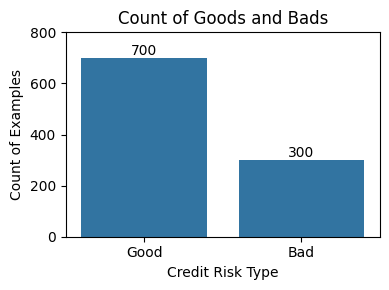

In [67]:
#========================================================================
# Step 2: Plot Response

# Summarise for the plot
df_smry=df['bad_flag'].value_counts().reset_index()
df_smry['bad_flag']=df_smry['bad_flag'].map({0:'Good', 1:'Bad'})

# Response plot
plt.figure(figsize=(4,3))
ax=sns.barplot(df_smry, x='bad_flag', y='count')
ax.bar_label(ax.containers[0])
ax.set_xlabel('Credit Risk Type')
ax.set_ylabel('Count of Examples')
plt.ylim(0, 800) 
plt.title('Count of Goods and Bads')
plt.tight_layout()
plt.savefig("credit-data-count-goods-bads.png", dpi=300)
plt.show()
#========================================================================

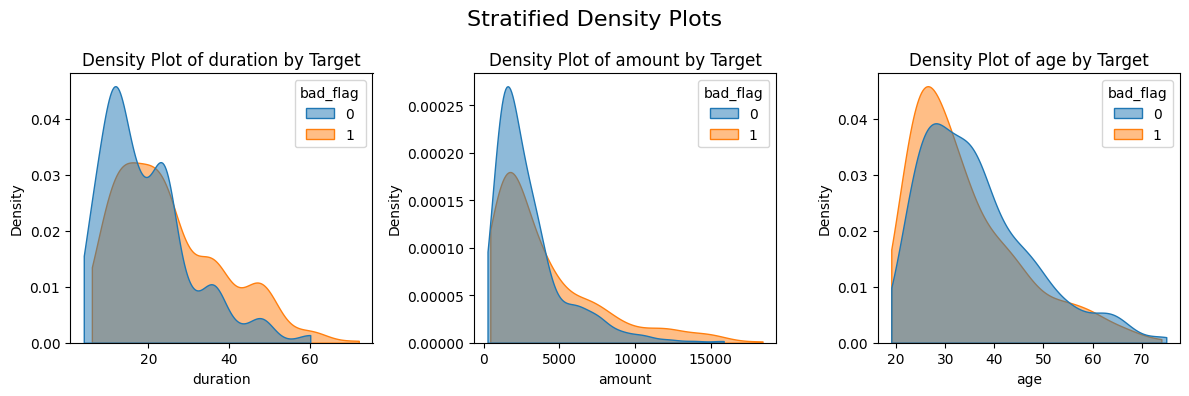

In [68]:
#========================================================================
# Step 3: Plot Numeric Features

# Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('bad_flag')
num_numeric_cols=len(numeric_cols)

# KDE Plots
fig, axes = plt.subplots(1, num_numeric_cols, figsize=(12, 4))
for i, this_var in enumerate(numeric_cols):
    sns.kdeplot(data=df, 
                x=this_var, 
                hue='bad_flag', 
                fill=True, 
                common_norm=False,
                cut=0,
                alpha=0.5,
                ax=axes[i])
    axes[i].set_title(f'Density Plot of {this_var} by Target', fontsize=12)
fig.suptitle('Stratified Density Plots', fontsize=16)
plt.tight_layout()
plt.savefig("credit-data-numeric-features.png", dpi=300)
plt.show()
#========================================================================

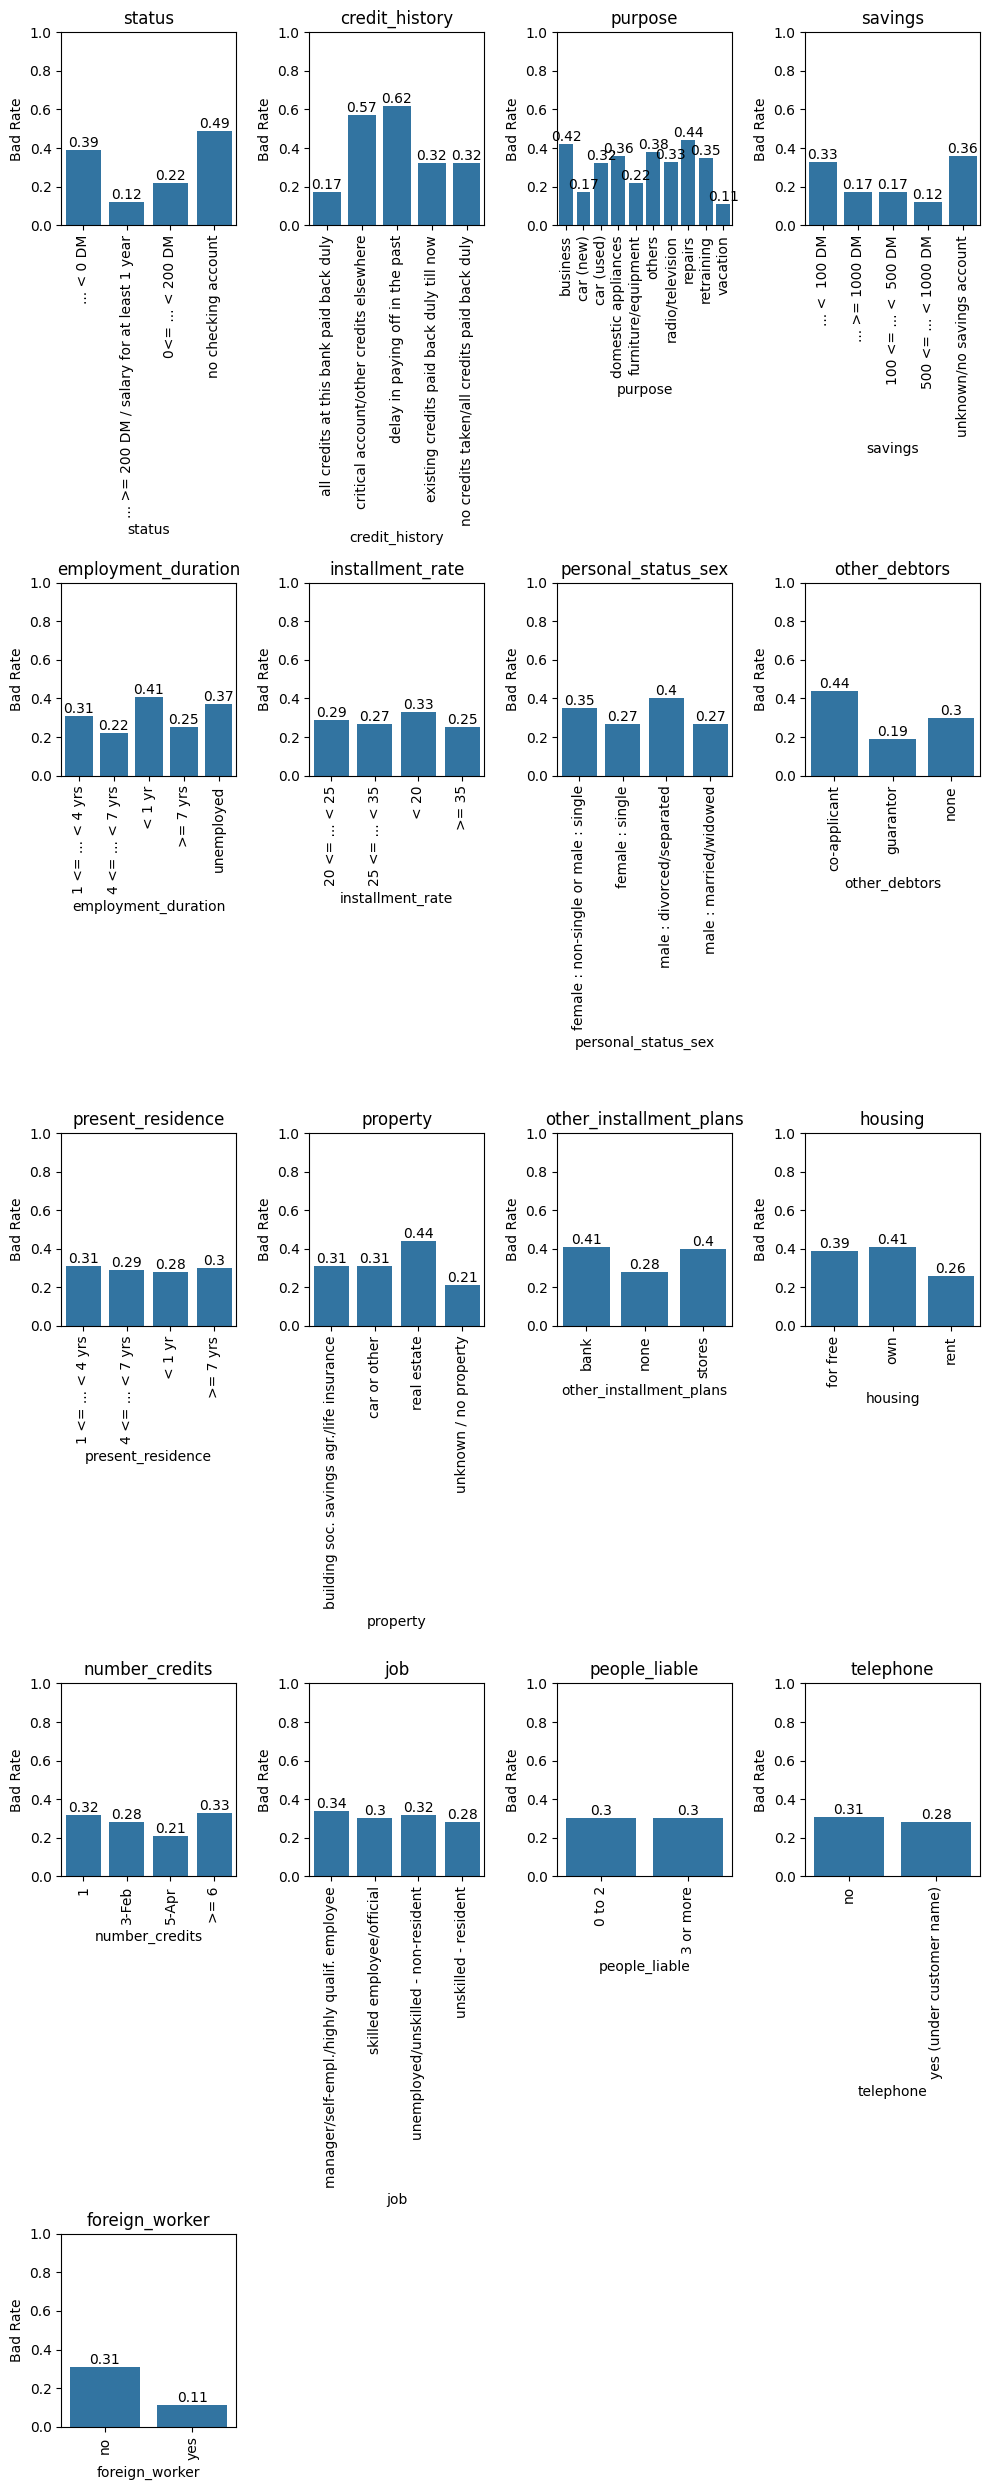

In [69]:
#========================================================================
# Step 4: Plot Categorical Features

# Identify categorical columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
num_categorical_cols = len(categorical_cols)

# Set up grid dimensions
cols = 4
rows = (num_categorical_cols + cols - 1) // cols  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop over categorical columns
for i, col in enumerate(categorical_cols):
    df_smry = df[['bad_flag', col]].groupby(col).mean().reset_index().round(2)

    ax = axes[i]  # Get the current axis
    sns.barplot(data=df_smry, x=col, y='bad_flag', ax=ax)
    ax.bar_label(ax.containers[0])
    ax.set_xlabel(col)
    ax.set_ylabel('Bad Rate')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 1)
    #ax.set_title(f'Bad Rate by {col}')
    ax.set_title(f'{col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("credit-data-categorical-features.png", dpi=300)
plt.show()
#========================================================================

In [25]:
#========================================================================
# Step 5: Feature Importance
#df



In [26]:
#========================================================================
# Step 6: Prepare for Modelling

# One-Hot Encoding
df2=copy.deepcopy(pd.get_dummies(df,dtype=int))
df2.columns=df2.columns.str.replace('-', '_').str.replace(' ', '_')

# X and y
X=df2.drop(['bad_flag'], axis=1)
y=df2['bad_flag']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#========================================================================

In [13]:
#========================================================================
# Step 7: Modelling
#- XGBoost
#- LightGBM
#- CatBoost
#- Random Forest
#- Logistic Regression
#- Naive Bayes
#- K-Nearest Neighbours
#- Support Vector Machine
#- Neural Network (Multilayer Perceptron)
#- Linear Discriminant Analysis

In [14]:
#--------------------
# XGBoost
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
pred_xgb=pd.DataFrame({'model': 'xgb', 'target': y_test, 'pred': model_xgb.predict_proba(X_test)[:,1]})
#--------------------

In [15]:
#--------------------
# Light GBM
model_lgb=LGBMClassifier(verbose=-1)
model_lgb.fit(X_train, y_train)
pred_lgb=pd.DataFrame({'model': 'lgb', 'target': y_test, 'pred': model_lgb.predict_proba(X_test)[:,1]})
#--------------------

In [16]:
#--------------------
# Catboost
model_cat=CatBoostClassifier(verbose=False)
model_cat.fit(X_train, y_train)
pred_cat=pd.DataFrame({'model': 'cat', 'target': y_test, 'pred': model_cat.predict_proba(X_test)[:,1]})
#--------------------

In [17]:
#--------------------
# Random Forrest
model_rfc=RandomForestClassifier()
model_rfc.fit(X_train, y_train)
pred_rfc=pd.DataFrame({'model': 'rf', 'target': y_test, 'pred': model_rfc.predict_proba(X_test)[:,1]})
#--------------------

In [18]:
#--------------------
# Logistic Regression
model_lrg=LogisticRegression(penalty=None, solver='newton-cg')
model_lrg.fit(X_train, y_train)
pred_lrg=pd.DataFrame({'model': 'lr', 'target': y_test, 'pred': model_lrg.predict_proba(X_test)[:,1]})
#--------------------

c:\Users\markt\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [19]:
#--------------------
# Naive Bayes
model_nb=GaussianNB()
model_nb.fit(X_train,  y_train)
pred_nb=pd.DataFrame({'model': 'nb', 'target': y_test, 'pred': model_nb.predict_proba(X_test)[:,1]})
#--------------------

In [20]:
#--------------------
# K-Nearest Neighbours
model_knn=KNeighborsClassifier()
model_knn.fit(X_train, y_train)
pred_knn=pd.DataFrame({'model': 'knn', 'target': y_test, 'pred': model_knn.predict_proba(X_test)[:,1]})
#--------------------

In [21]:
#--------------------
# Support Vector Machine
model_svc=SVC(probability=True)
model_svc.fit(X_train, y_train)
pred_svc=pd.DataFrame({'model': 'svc', 'target': y_test, 'pred': model_svc.predict_proba(X_test)[:,1]})
#--------------------

In [22]:
#--------------------
# Neural Network - Multilayer Perception
model_mlp=MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000)
model_mlp.fit(X_train, y_train)
pred_mlp=pd.DataFrame({'model': 'nn', 'target': y_test, 'pred': model_mlp.predict_proba(X_test)[:,1]})
#--------------------

In [23]:
#--------------------
# Linear Discriminant Analysis
model_lda=LinearDiscriminantAnalysis()
model_lda.fit(X_train, y_train)
pred_lda=pd.DataFrame({'model': 'lda', 'target': y_test, 'pred': model_lda.predict_proba(X_test)[:,1]})
#--------------------
#========================================================================

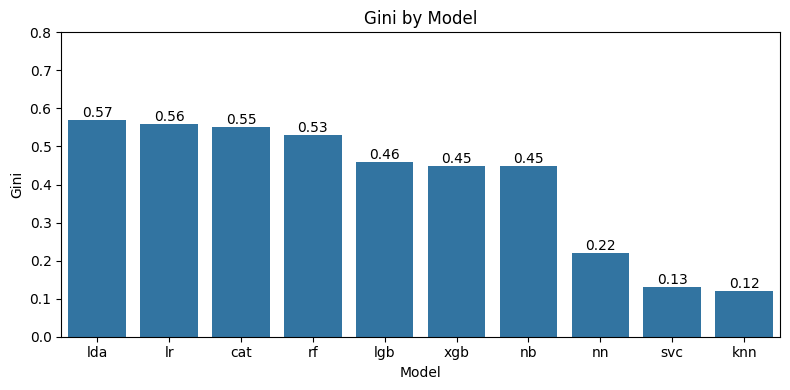

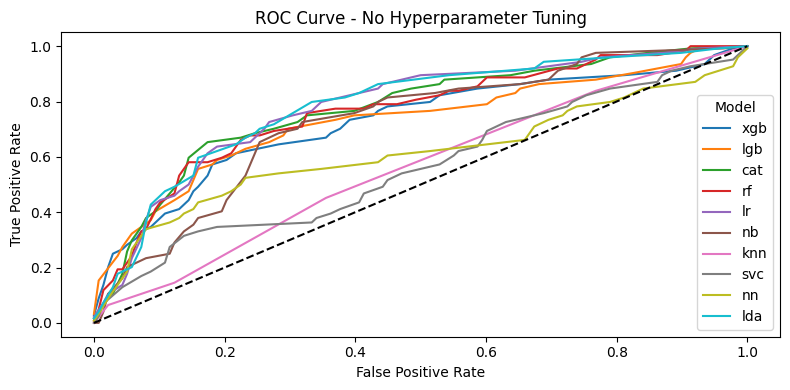

In [24]:
#========================================================================
# Step 8: Collate Results

#--------------------
# Join all predictions
pred=pd.concat([pred_xgb, 
                pred_lgb, 
                pred_cat, 
                pred_rfc, 
                pred_lrg, 
                pred_nb, 
                pred_knn, 
                pred_svc, 
                pred_mlp, 
                pred_lda], axis=0).reset_index(drop=True)

#--------------------
# Gini
gini_df=gini_group(y_true=pred['target'], 
                   y_score=pred['pred'], 
                   group=pred['model'], 
                   round=2)\
                  .sort_values('Gini', ascending=False)\
                  .reset_index()

# Gini Barplot
plt.figure(figsize=(8, 4))
ax=sns.barplot(data=gini_df, y='Gini', x='group')
ax.bar_label(ax.containers[0])
plt.ylabel('Gini')
plt.xlabel('Model')
plt.ylim(0, 0.8)
plt.title('Gini by Model')
plt.tight_layout()
plt.savefig("credit-data-gini.png", dpi=300)
plt.show()
#--------------------

#--------------------
# ROC Curve
roc_curve_df=roc_curve_group(y_true=pred['target'], 
                             y_score=pred['pred'], 
                             group=pred['model'], 
                             round=6)

# Plot ROC Curve
plt.figure(figsize=(8, 4))
sns.lineplot(data=roc_curve_df, x='fpr', y='tpr', hue='Model', errorbar=None)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - No Hyperparameter Tuning')
plt.tight_layout()
plt.savefig("credit-data-roc-curve.png", dpi=300)
plt.show()
#--------------------
#========================================================================